In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/My Drive/Facebook_Marketplace_data.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


df.head() gives output of first 5 rows

In [ ]:
display(df.head())

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


df.info() helps us see column types

In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

None

df.describe() to see the statistics

In [ ]:
display(df.describe())

,status_id,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
count,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,7050.000000,0.0,0.0,0.0,0.0
mean,3525.500000,230.117163,224.356028,40.022553,215.043121,12.728652,1.289362,0.696454,0.243688,0.113191,NaN,NaN,NaN,NaN
std,2035.304031,462.625309,889.636820,131.599965,449.472357,39.972930,8.719650,3.957183,1.597156,0.726812,NaN,NaN,NaN,NaN
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,1763.250000,17.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
50%,3525.500000,59.500000,4.000000,0.000000,58.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
75%,5287.750000,219.000000,23.000000,4.000000,184.750000,3.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
max,7050.000000,4710.000000,20990.000000,3424.000000,4710.000000,657.000000,278.000000,157.000000,51.000000,31.000000,NaN,NaN,NaN,NaN


df.shape to see dimensions

In [ ]:
display(df.shape)

(7050, 16)

(df.isnull().sum()) for counting missing values


In [ ]:
display(df.isnull().sum())

,0
status_id,0
status_type,0
status_published,0
num_reactions,0
num_comments,0
num_shares,0
num_likes,0
num_loves,0
num_wows,0
num_hahas,0


Cleaning the data by removing empty columns

In [ ]:
columns_to_drop = ['Column1', 'Column2', 'Column3', 'Column4']
df_clean = df.drop(columns=columns_to_drop)

dropna removes missing value(NaN or none)

In [ ]:
df_clean=df_clean.dropna()

Question 5

In [ ]:
counts = df_clean['status_type'].value_counts()
print(counts)

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


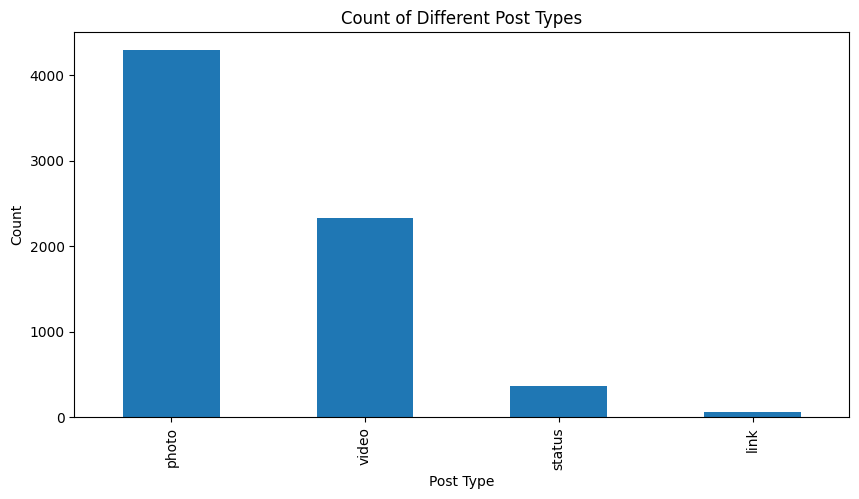

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
counts.plot(kind='bar')
plt.title('Count of Different Post Types')
plt.xlabel('Post Type')
plt.ylabel('Count')
plt.show()

Question 6

In [ ]:
avg_by_type = df_clean.groupby('status_type')[['num_reactions', 'num_comments', 'num_shares']].mean()
print(avg_by_type)


             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


<Figure size 1200x600 with 0 Axes>

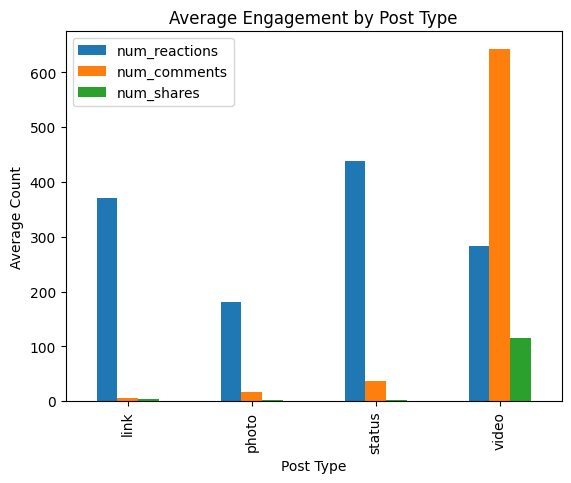

In [ ]:
plt.figure(figsize=(12, 6))
avg_by_type.plot(kind='bar')
plt.title('Average Engagement by Post Type')
plt.xlabel('Post Type')
plt.ylabel('Average Count')
plt.legend()
plt.show()

Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select features
features = ['num_reactions', 'num_comments', 'num_shares',
            'num_likes', 'num_loves', 'num_wows', 'num_hahas', 'num_sads', 'num_angrys']
X = df_clean[features].copy()

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Original shape:", X.shape)
print("Scaled shape:", X_scaled.shape)

Original shape: (7050, 9)
Scaled shape: (7050, 9)


fit → Learns the mean and standard deviation of each column
transform → Rescales every value using the formula:
z = (value - mean) / std_deviation

Question 4

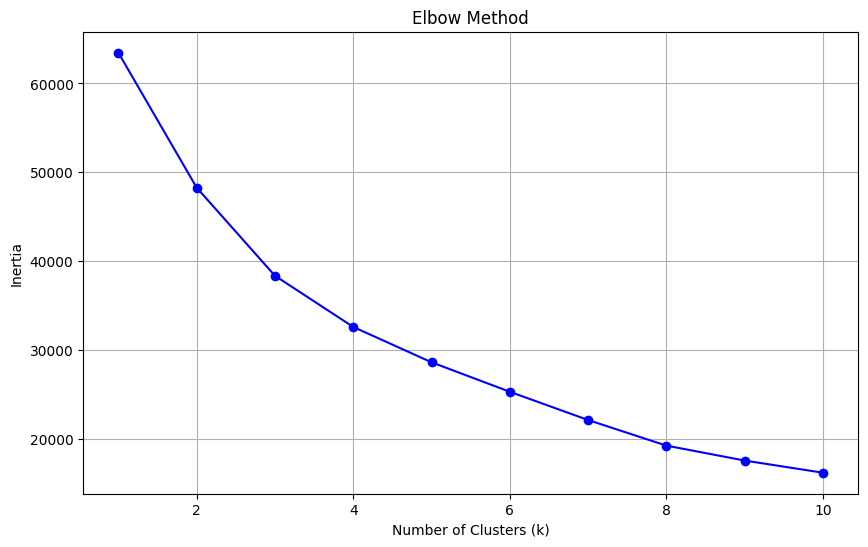

In [ ]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True)
plt.show()


Question 3

In [ ]:
optimal_k = 4 # Change based on your elbow plot

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

# Add to dataframe
df_clean['Cluster'] = clusters

# Count
print(df_clean['Cluster'].value_counts().sort_index())

# Analyze cluster characteristics
for i in range(optimal_k):
    print(f"\n=== Cluster {i} ===")
    cluster_data = df_clean[df_clean['Cluster'] == i][features]
    print(cluster_data.mean())

Cluster
0    6322
1     330
2     372
3      26
Name: count, dtype: int64

=== Cluster 0 ===
num_reactions    111.235527
num_comments      85.856216
num_shares        18.488611
num_likes        103.664030
num_loves          6.556628
num_wows           0.537646
num_hahas          0.305599
num_sads           0.125751
num_angrys         0.043499
dtype: float64

=== Cluster 1 ===
num_reactions     602.287879
num_comments     2950.948485
num_shares        423.684848
num_likes         468.927273
num_loves         117.396970
num_wows            4.687879
num_hahas           7.190909
num_sads            2.639394
num_angrys          1.433333
dtype: float64

=== Cluster 2 ===
num_reactions    1823.311828
num_comments       61.333333
num_shares         11.645161
num_likes        1817.534946
num_loves           3.104839
num_wows            2.435484
num_hahas           0.198925
num_sads            0.032258
num_angrys          0.005376
dtype: float64

=== Cluster 3 ===
num_reactions    1618.000000
nu

value_counts() → counts how many posts are in each cluster

sort_index() → shows them in order (Cluster 0, 1, 2, 3)

fit → Model learns the 4 cluster centers from the data  

predict → Assigns every row a cluster label (0, 1, 2, or 3)

df_clean[df_clean['Cluster'] == i] → picks only rows belonging to cluster i
[features] → keeps only our 9 engagement columns

**Question 1**


In [ ]:
import pandas as pd
df_clean['status_published'] = pd.to_datetime(df_clean['status_published'])

In [ ]:
df_clean['upload_hour'] = df_clean['status_published'].dt.hour


/tmp/ipykernel_1554/2866736767.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_reactions = df_clean.groupby('Day name')['num_reactions'].mean()


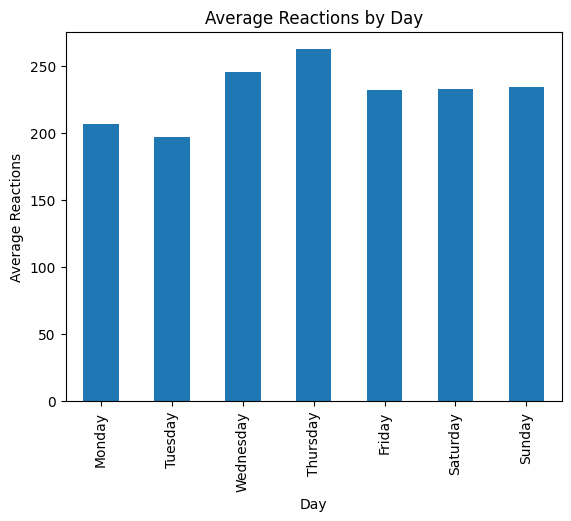

In [ ]:
df_clean['day_name'] = df_clean['status_published'].dt.day_name()
month_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

df_clean['Day name'] = pd.Categorical(
    df_clean['day_name'],
    categories=month_order,
    ordered=True
)

day_reactions = df_clean.groupby('Day name')['num_reactions'].mean()

day_reactions.plot(kind='bar')
plt.ylabel('Average Reactions')
plt.xlabel('Day')
plt.title('Average Reactions by Day')
plt.show()

/tmp/ipykernel_1554/2649423234.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_reactions = df_clean.groupby('month')['num_reactions'].mean()


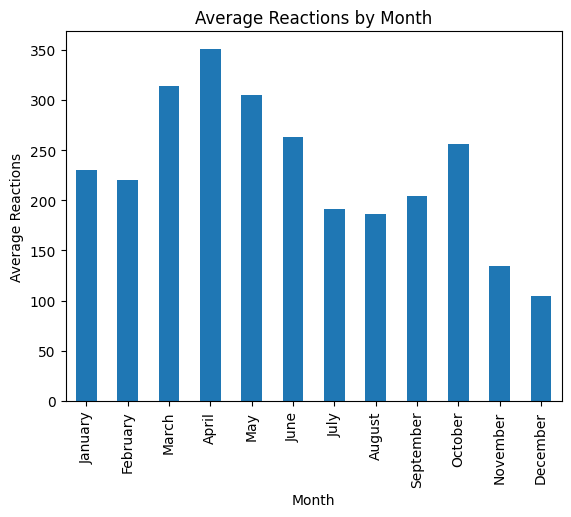

In [ ]:
df_clean['month'] = df_clean['status_published'].dt.month_name()
month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

df_clean['month'] = pd.Categorical(
    df_clean['month'],
    categories=month_order,
    ordered=True
)

day_reactions = df_clean.groupby('month')['num_reactions'].mean()

day_reactions.plot(kind='bar')
plt.ylabel('Average Reactions')
plt.xlabel('Month')
plt.title('Average Reactions by Month')
plt.show()